In [1]:
import pandas as pd
import numpy as np
import formula_descriptors

# Load Cytotoxicity data

In [3]:
dataset = pd.read_csv("kim_model_data_for_ml.csv")
dataset

,Concentration,Compound,Cytotoxicity
0,0.1,PFHxS,3.100000e-18
1,5.0,PFHxS,2.940000e-07
2,10.0,PFHxS,2.270000e-05
3,20.0,PFHxS,1.494304e-03
4,40.0,PFHxS,7.297822e-02
...,...,...,...
721,160.0,Mix48,5.920338e+00
722,320.0,Mix48,8.215506e+01
723,640.0,Mix48,9.973611e+01
724,1280.0,Mix48,9.974000e+01


### Normalize

In [4]:
from sklearn.preprocessing import MinMaxScaler

# Clip the upper to be 100
dataset['Cytotoxicity'] = dataset['Cytotoxicity'].clip(upper=100)

# Initialize the MinMaxScaler to scale values to the range [0, 1]
scaler = MinMaxScaler()

# Fit the scaler on the target variable and transform it
dataset["Cytotoxicity"] = scaler.fit_transform(dataset["Cytotoxicity"].values.reshape(-1, 1))

dataset["Concentration"] = dataset["Concentration"]/1000000

dataset

,Concentration,Compound,Cytotoxicity
0,1.000000e-07,PFHxS,3.100000e-20
1,5.000000e-06,PFHxS,2.940000e-09
2,1.000000e-05,PFHxS,2.270000e-07
3,2.000000e-05,PFHxS,1.494304e-05
4,4.000000e-05,PFHxS,7.297822e-04
...,...,...,...
721,1.600000e-04,Mix48,5.920338e-02
722,3.200000e-04,Mix48,8.215506e-01
723,6.400000e-04,Mix48,9.973611e-01
724,1.280000e-03,Mix48,9.974000e-01


# Generate training data (single ingredient only)

In [6]:
train = pd.read_csv("KIM_rcdk_descriptors.csv", index_col=0)
train

,Fsp3,XLogP,MW,LipinskiFailures,nRotB,MLogP,nAtomP,nAtomLC,nB,nBase,...,ATSp5,ATSm1,ATSm2,ATSm3,ATSm4,ATSm5,nHBDon,nHBAcc,bpol,apol
compound,,,,,,,,,,,,,,,,,,,,,
"2,4-DCP",0.000000,0.415230,0.099864,0.0,0.000000,0.466667,0.304348,0.214286,0.269231,0,...,0.101266,0.032950,0.000000,0.212248,0.158705,0.135702,1,0.142857,0.000000,0.100511
"2,5-DCP",0.000000,0.415230,0.099864,0.0,0.000000,0.466667,0.304348,0.214286,0.269231,0,...,0.100439,0.032950,0.000000,0.212248,0.158705,0.095022,1,0.142857,0.000000,0.100511
pPB,0.300000,0.367906,0.151286,0.0,0.190476,0.600000,0.434783,0.500000,0.423077,0,...,0.260431,0.000000,0.012331,0.187578,0.130924,0.110550,1,0.428571,0.166541,0.234239
bPB,0.363636,0.419001,0.193222,0.0,0.238095,0.633333,0.434783,0.571429,0.461538,0,...,0.295096,0.003336,0.023616,0.199693,0.138339,0.121884,1,0.428571,0.200320,0.277251
BP-3,0.071429,0.473958,0.294922,0.0,0.142857,0.733333,0.695652,0.571429,0.615385,0,...,0.631677,0.013344,0.068754,0.279138,0.207537,0.211642,1,0.285714,0.166541,0.332120
TCS,0.000000,0.580011,0.478188,0.0,0.095238,0.600000,0.608696,0.571429,0.615385,0,...,0.647411,0.087953,0.131082,0.433126,0.307052,0.321462,1,0.142857,0.086759,0.316604
Pb,0.000000,0.262662,0.444047,0.0,0.000000,0.266667,0.000000,0.000000,0.000000,0,...,0.000000,1.000000,1.000000,0.069796,0.000000,0.000000,0,0.000000,0.062218,0.000000
Cu,0.000000,0.000000,0.089723,0.0,0.000000,0.166667,0.217391,0.000000,0.076923,0,...,0.000000,0.089720,0.011171,0.093225,0.000000,0.000000,0,0.571429,0.049117,0.014571
Se,0.000000,0.137302,0.129569,0.0,0.000000,0.166667,0.173913,0.000000,0.038462,1,...,0.000000,0.135263,0.147108,0.028732,0.000000,0.000000,0,0.428571,0.057027,0.586949


In [7]:
training_set = dataset.merge(train, left_on='Compound', right_index=True)
training_set

,Concentration,Compound,Cytotoxicity,Fsp3,XLogP,MW,LipinskiFailures,nRotB,MLogP,nAtomP,...,ATSp5,ATSm1,ATSm2,ATSm3,ATSm4,ATSm5,nHBDon,nHBAcc,bpol,apol
0,1.000000e-07,PFHxS,3.100000e-20,1.0,0.568786,0.808775,0.0,0.285714,0.0,0.130435,...,0.652788,0.118944,0.289638,0.905200,0.835594,0.811344,1,0.428571,0.278021,0.175376
1,5.000000e-06,PFHxS,2.940000e-09,1.0,0.568786,0.808775,0.0,0.285714,0.0,0.130435,...,0.652788,0.118944,0.289638,0.905200,0.835594,0.811344,1,0.428571,0.278021,0.175376
2,1.000000e-05,PFHxS,2.270000e-07,1.0,0.568786,0.808775,0.0,0.285714,0.0,0.130435,...,0.652788,0.118944,0.289638,0.905200,0.835594,0.811344,1,0.428571,0.278021,0.175376
3,2.000000e-05,PFHxS,1.494304e-05,1.0,0.568786,0.808775,0.0,0.285714,0.0,0.130435,...,0.652788,0.118944,0.289638,0.905200,0.835594,0.811344,1,0.428571,0.278021,0.175376
4,4.000000e-05,PFHxS,7.297822e-04,1.0,0.568786,0.808775,0.0,0.285714,0.0,0.130435,...,0.652788,0.118944,0.289638,0.905200,0.835594,0.811344,1,0.428571,0.278021,0.175376
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
303,1.600000e-04,TBOEP,1.507378e-01,1.0,0.408944,0.803862,0.5,1.000000,0.7,0.217391,...,0.524556,0.072553,0.276408,0.441231,0.282103,0.334283,0,1.000000,0.886129,0.775382
304,3.200000e-04,TBOEP,5.331098e-01,1.0,0.408944,0.803862,0.5,1.000000,0.7,0.217391,...,0.524556,0.072553,0.276408,0.441231,0.282103,0.334283,0,1.000000,0.886129,0.775382
305,6.400000e-04,TBOEP,9.720049e-01,1.0,0.408944,0.803862,0.5,1.000000,0.7,0.217391,...,0.524556,0.072553,0.276408,0.441231,0.282103,0.334283,0,1.000000,0.886129,0.775382
306,1.280000e-03,TBOEP,9.918885e-01,1.0,0.408944,0.803862,0.5,1.000000,0.7,0.217391,...,0.524556,0.072553,0.276408,0.441231,0.282103,0.334283,0,1.000000,0.886129,0.775382


In [8]:
#X_train = np.array(training_set.drop(columns=["Compound", "Cytotoxicity"]))
#y_train = np.array(training_set.Cytotoxicity.values)

# Now generate test data

### load mixture mapping data

In [9]:
mixture_info = pd.read_json('mixture_data_for_mapping.json', orient='index')
mixture_info

,Compound Names,Smiles,Mole Fractions,Molecular Weights (g/mol)
Mix1,"[PFHxS, 2,4-DCP, 2,5-DCP, pPB, bPB, Hg, Cu, Se...",[C(C(C(C(F)(F)S(=O)(=O)O)(F)F)(F)F)(C(C(F)(F)F...,"[7.29, 20.36, 18.92, 16.71, 11.88, 0.72, 0.33,...","[438.2, 163.0, 20.74, 180.2, 194.23, 251.1, 24..."
Mix2,"[PFNA, PFOA, BP-3, TCS, pPB, Hg, Cd, Sb]",[OC(=O)C(C(C(C(C(C(C(C(F)(F)F)(F)F)(F)F)(F)F)(...,"[14.3, 17.56, 26.52, 0.59, 31.49, 1.35, 0.1, 8...","[464.08, 414.07, 228.1, 289.54, 180.2, 251.1, ..."
Mix3,"[BP-3, bPB, Co, Cu, Pb, Cd, Se, Zn, Sb, Ni]","[COc1ccc(c(c1)O)C(=O)c1ccccc1, CCCCOC(=O)c1ccc...","[14.13, 11.92, 16.96, 0.33, 23.63, 0.05, 0.26,...","[228.1, 194.23, 129.84, 249.7, 278.0, 183.3, 1..."
Mix4,"[TEHP, TDCPP, EHDPHP, TPhP, TnBP, TCPP, TBOEP]","[CCCCC(COP(=O)(OCC(CCCC)CC)OCC(CCCC)CC)CC, ClC...","[26.29, 14.07, 8.58, 5.27, 16.56, 17.39, 11.85]","[434.63, 430.9, 362.4, 362.4, 326.3, 398.5, 39..."
Mix5,"[2,4-DCP, 2,5-DCP, pPB, bPB, BP-3, TCS, TnBP, ...","[Clc1ccc(c(c1)Cl)O, Clc1ccc(c(c1)O)Cl, CCCOC(=...","[19.06, 17.71, 15.65, 11.12, 13.18, 0.29, 9.71...","[163.0, 163.0, 180.2, 194.23, 228.1, 289.54, 3..."
Mix6,"[PFNA, PFOA, PFHxS, EHDPHP, TBOEP, TDCPP, TEHP...",[OC(=O)C(C(C(C(C(C(C(C(F)(F)F)(F)F)(F)F)(F)F)(...,"[14.45, 17.74, 13.87, 10.22, 14.13, 16.77, 6.5...","[464.08, 414.07, 438.2, None, 398.5, 430.9, 43..."
Mix7,"[Co, Cu, Pb, Cd, Se, Zn]","[Cl[Co]Cl, [O-]S(=O)(=O)[O-], Cl[Pb]Cl, Cl[Cd]...","[22.72, 0.45, 31.65, 0.07, 0.35000000000000003...","[129.84, 249.7, 278.0, 183.3, 172.95, 287.6]"
Mix8,"[Pb, Cd, Zn, Hg, TBOEP, TDCPP, TEHP]","[Cl[Pb]Cl, Cl[Cd]Cl, [O-]S(=O)(=O)[O-], C[Hg]C...","[39.88, 0.09, 25.5, 1.21, 12.58, 14.93, 5.8100...","[278.0, 183.3, 287.6, 251.1, 398.5, 430.9, 434..."
Mix9,"[PFNA, PFOA, PFHxS, 2,4-DCP, 2,5-DCP, pPB, bPB...",[OC(=O)C(C(C(C(C(C(C(C(F)(F)F)(F)F)(F)F)(F)F)(...,"[7.13, 8.76, 6.85, 19.13, 17.77, 15.7, 11.16, ...","[464.08, 414.07, 438.2, 163.0, 163.0, 180.2, 1..."
Mix10,"[PFNA, PFOA, PFHxS, Co, Cu, Se, Sb, Ni]",[OC(=O)C(C(C(C(C(C(C(C(F)(F)F)(F)F)(F)F)(F)F)(...,"[12.82, 15.74, 12.31, 28.53, 0.56, 0.44, 7.25,...","[464.08, 414.07, 438.2, 129.84, 249.7, 172.95,..."


In [11]:
mixture_info = mixture_info.drop(index='Mix3')
mixture_info

,Compound Names,Smiles,Mole Fractions,Molecular Weights (g/mol)
Mix1,"[PFHxS, 2,4-DCP, 2,5-DCP, pPB, bPB, Hg, Cu, Se...",[C(C(C(C(F)(F)S(=O)(=O)O)(F)F)(F)F)(C(C(F)(F)F...,"[7.29, 20.36, 18.92, 16.71, 11.88, 0.72, 0.33,...","[438.2, 163.0, 20.74, 180.2, 194.23, 251.1, 24..."
Mix2,"[PFNA, PFOA, BP-3, TCS, pPB, Hg, Cd, Sb]",[OC(=O)C(C(C(C(C(C(C(C(F)(F)F)(F)F)(F)F)(F)F)(...,"[14.3, 17.56, 26.52, 0.59, 31.49, 1.35, 0.1, 8...","[464.08, 414.07, 228.1, 289.54, 180.2, 251.1, ..."
Mix4,"[TEHP, TDCPP, EHDPHP, TPhP, TnBP, TCPP, TBOEP]","[CCCCC(COP(=O)(OCC(CCCC)CC)OCC(CCCC)CC)CC, ClC...","[26.29, 14.07, 8.58, 5.27, 16.56, 17.39, 11.85]","[434.63, 430.9, 362.4, 362.4, 326.3, 398.5, 39..."
Mix5,"[2,4-DCP, 2,5-DCP, pPB, bPB, BP-3, TCS, TnBP, ...","[Clc1ccc(c(c1)Cl)O, Clc1ccc(c(c1)O)Cl, CCCOC(=...","[19.06, 17.71, 15.65, 11.12, 13.18, 0.29, 9.71...","[163.0, 163.0, 180.2, 194.23, 228.1, 289.54, 3..."
Mix6,"[PFNA, PFOA, PFHxS, EHDPHP, TBOEP, TDCPP, TEHP...",[OC(=O)C(C(C(C(C(C(C(C(F)(F)F)(F)F)(F)F)(F)F)(...,"[14.45, 17.74, 13.87, 10.22, 14.13, 16.77, 6.5...","[464.08, 414.07, 438.2, None, 398.5, 430.9, 43..."
Mix7,"[Co, Cu, Pb, Cd, Se, Zn]","[Cl[Co]Cl, [O-]S(=O)(=O)[O-], Cl[Pb]Cl, Cl[Cd]...","[22.72, 0.45, 31.65, 0.07, 0.35000000000000003...","[129.84, 249.7, 278.0, 183.3, 172.95, 287.6]"
Mix8,"[Pb, Cd, Zn, Hg, TBOEP, TDCPP, TEHP]","[Cl[Pb]Cl, Cl[Cd]Cl, [O-]S(=O)(=O)[O-], C[Hg]C...","[39.88, 0.09, 25.5, 1.21, 12.58, 14.93, 5.8100...","[278.0, 183.3, 287.6, 251.1, 398.5, 430.9, 434..."
Mix9,"[PFNA, PFOA, PFHxS, 2,4-DCP, 2,5-DCP, pPB, bPB...",[OC(=O)C(C(C(C(C(C(C(C(F)(F)F)(F)F)(F)F)(F)F)(...,"[7.13, 8.76, 6.85, 19.13, 17.77, 15.7, 11.16, ...","[464.08, 414.07, 438.2, 163.0, 163.0, 180.2, 1..."
Mix10,"[PFNA, PFOA, PFHxS, Co, Cu, Se, Sb, Ni]",[OC(=O)C(C(C(C(C(C(C(C(F)(F)F)(F)F)(F)F)(F)F)(...,"[12.82, 15.74, 12.31, 28.53, 0.56, 0.44, 7.25,...","[464.08, 414.07, 438.2, 129.84, 249.7, 172.95,..."
Mix11,"[PFOA, PFHxS, Pb, Hg, Zn, TDCPP, TPhP, 2,5-DCP...",[OC(=O)C(C(C(C(C(C(C(F)(F)F)(F)F)(F)F)(F)F)(F)...,"[9.43, 7.37, 23.82, 0.72, 15.23, 8.92, 3.34, 1...","[414.07, 438.2, 278.0, 251.1, 287.6, 430.9, 36..."


### Calculate formula molecular descriptors

In [12]:
mix_emb_df = formula_descriptors.formulate_descriptors(mixture_info, train)
mix_emb_df

,Fsp3,XLogP,MW,LipinskiFailures,nRotB,MLogP,nAtomP,nAtomLC,nB,nBase,...,ATSp5,ATSm1,ATSm2,ATSm3,ATSm4,ATSm5,nHBDon,nHBAcc,bpol,apol
Mix1,0.173430,0.379822,0.254198,0.00000,0.080943,0.424963,0.254530,0.266850,0.287712,0.0026,...,0.165785,0.264623,0.266087,0.221240,0.161566,0.137707,0.7516,0.212886,0.087466,0.125966
Mix2,0.407674,0.506313,0.449914,0.15930,0.211438,0.427077,0.366548,0.481879,0.589254,0.0000,...,0.456160,0.086065,0.180457,0.456136,0.394107,0.385535,0.9046,0.302600,0.186983,0.231748
Mix4,0.895920,0.610802,0.723086,0.56110,0.690957,0.673500,0.303422,0.664700,0.768350,0.0000,...,0.708866,0.089681,0.252559,0.450782,0.335067,0.437815,0.0000,0.622271,0.679048,0.660961
Mix5,0.295901,0.422538,0.240371,0.04855,0.183419,0.558093,0.395935,0.414414,0.433965,0.0000,...,0.308734,0.030992,0.058919,0.256667,0.188287,0.179897,0.7701,0.336757,0.187529,0.254801
Mix6,0.837549,0.612779,0.839881,0.48295,0.527743,0.370057,0.279887,0.608800,0.845669,0.0000,...,0.711590,0.113908,0.274491,0.692767,0.617241,0.690907,0.4606,0.520200,0.466153,0.448388
Mix7,0.000000,0.143474,0.160953,0.00000,0.000000,0.180240,0.045587,0.000000,0.016050,0.0035,...,0.000000,0.356704,0.359991,0.057386,0.000000,0.000000,0.0000,0.119729,0.049156,0.010098
Mix8,0.345300,0.295003,0.494520,0.19565,0.269214,0.344070,0.127870,0.239586,0.286619,0.0000,...,0.249606,0.477598,0.508304,0.215462,0.131311,0.192492,0.0000,0.390029,0.272347,0.234812
Mix9,0.305652,0.476113,0.323745,0.07945,0.151571,0.443983,0.352478,0.412443,0.495788,0.0000,...,0.342290,0.042020,0.073372,0.378688,0.327761,0.304271,1.0001,0.280771,0.129004,0.194418
Mix10,0.374781,0.435250,0.384259,0.14280,0.136476,0.169030,0.055291,0.204714,0.354535,0.0044,...,0.262163,0.122231,0.259989,0.434814,0.368229,0.362260,0.4087,0.139443,0.152028,0.087936
Mix11,0.296322,0.361778,0.405036,0.09175,0.141624,0.316517,0.218326,0.245750,0.343077,0.0000,...,0.258158,0.304959,0.326701,0.309691,0.247258,0.261203,0.4796,0.294471,0.140697,0.147893


In [13]:
testing_set = dataset.merge(mix_emb_df, left_on='Compound', right_index=True)
testing_set

,Concentration,Compound,Cytotoxicity,Fsp3,XLogP,MW,LipinskiFailures,nRotB,MLogP,nAtomP,...,ATSp5,ATSm1,ATSm2,ATSm3,ATSm4,ATSm5,nHBDon,nHBAcc,bpol,apol
99,1.000000e-07,Mix1,0.000102,0.17343,0.379822,0.254198,0.00000,0.080943,0.424963,0.254530,...,0.165785,0.264623,0.266087,0.221240,0.161566,0.137707,0.7516,0.212886,0.087466,0.125966
100,5.000000e-06,Mix1,0.000137,0.17343,0.379822,0.254198,0.00000,0.080943,0.424963,0.254530,...,0.165785,0.264623,0.266087,0.221240,0.161566,0.137707,0.7516,0.212886,0.087466,0.125966
101,1.000000e-05,Mix1,0.000182,0.17343,0.379822,0.254198,0.00000,0.080943,0.424963,0.254530,...,0.165785,0.264623,0.266087,0.221240,0.161566,0.137707,0.7516,0.212886,0.087466,0.125966
102,2.000000e-05,Mix1,0.000314,0.17343,0.379822,0.254198,0.00000,0.080943,0.424963,0.254530,...,0.165785,0.264623,0.266087,0.221240,0.161566,0.137707,0.7516,0.212886,0.087466,0.125966
103,4.000000e-05,Mix1,0.000841,0.17343,0.379822,0.254198,0.00000,0.080943,0.424963,0.254530,...,0.165785,0.264623,0.266087,0.221240,0.161566,0.137707,0.7516,0.212886,0.087466,0.125966
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
721,1.600000e-04,Mix48,0.059203,0.18162,0.366852,0.397041,0.16035,0.181281,0.449200,0.204791,...,0.186441,0.454509,0.485495,0.207876,0.123193,0.115854,0.3393,0.237114,0.200300,0.201548
722,3.200000e-04,Mix48,0.821551,0.18162,0.366852,0.397041,0.16035,0.181281,0.449200,0.204791,...,0.186441,0.454509,0.485495,0.207876,0.123193,0.115854,0.3393,0.237114,0.200300,0.201548
723,6.400000e-04,Mix48,0.997361,0.18162,0.366852,0.397041,0.16035,0.181281,0.449200,0.204791,...,0.186441,0.454509,0.485495,0.207876,0.123193,0.115854,0.3393,0.237114,0.200300,0.201548
724,1.280000e-03,Mix48,0.997400,0.18162,0.366852,0.397041,0.16035,0.181281,0.449200,0.204791,...,0.186441,0.454509,0.485495,0.207876,0.123193,0.115854,0.3393,0.237114,0.200300,0.201548


In [14]:
#X_test = np.array(testing_set.drop(columns=["Compound", "Cytotoxicity"]))
#y_test = np.array(testing_set.Cytotoxicity.values)

In [15]:
altogether = pd.concat([training_set, testing_set], ignore_index=True)
altogether

,Concentration,Compound,Cytotoxicity,Fsp3,XLogP,MW,LipinskiFailures,nRotB,MLogP,nAtomP,...,ATSp5,ATSm1,ATSm2,ATSm3,ATSm4,ATSm5,nHBDon,nHBAcc,bpol,apol
0,1.000000e-07,PFHxS,3.100000e-20,1.00000,0.568786,0.808775,0.00000,0.285714,0.0000,0.130435,...,0.652788,0.118944,0.289638,0.905200,0.835594,0.811344,1.0000,0.428571,0.278021,0.175376
1,5.000000e-06,PFHxS,2.940000e-09,1.00000,0.568786,0.808775,0.00000,0.285714,0.0000,0.130435,...,0.652788,0.118944,0.289638,0.905200,0.835594,0.811344,1.0000,0.428571,0.278021,0.175376
2,1.000000e-05,PFHxS,2.270000e-07,1.00000,0.568786,0.808775,0.00000,0.285714,0.0000,0.130435,...,0.652788,0.118944,0.289638,0.905200,0.835594,0.811344,1.0000,0.428571,0.278021,0.175376
3,2.000000e-05,PFHxS,1.494304e-05,1.00000,0.568786,0.808775,0.00000,0.285714,0.0000,0.130435,...,0.652788,0.118944,0.289638,0.905200,0.835594,0.811344,1.0000,0.428571,0.278021,0.175376
4,4.000000e-05,PFHxS,7.297822e-04,1.00000,0.568786,0.808775,0.00000,0.285714,0.0000,0.130435,...,0.652788,0.118944,0.289638,0.905200,0.835594,0.811344,1.0000,0.428571,0.278021,0.175376
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
688,1.600000e-04,Mix48,5.920338e-02,0.18162,0.366852,0.397041,0.16035,0.181281,0.4492,0.204791,...,0.186441,0.454509,0.485495,0.207876,0.123193,0.115854,0.3393,0.237114,0.200300,0.201548
689,3.200000e-04,Mix48,8.215506e-01,0.18162,0.366852,0.397041,0.16035,0.181281,0.4492,0.204791,...,0.186441,0.454509,0.485495,0.207876,0.123193,0.115854,0.3393,0.237114,0.200300,0.201548
690,6.400000e-04,Mix48,9.973611e-01,0.18162,0.366852,0.397041,0.16035,0.181281,0.4492,0.204791,...,0.186441,0.454509,0.485495,0.207876,0.123193,0.115854,0.3393,0.237114,0.200300,0.201548
691,1.280000e-03,Mix48,9.974000e-01,0.18162,0.366852,0.397041,0.16035,0.181281,0.4492,0.204791,...,0.186441,0.454509,0.485495,0.207876,0.123193,0.115854,0.3393,0.237114,0.200300,0.201548


In [16]:
from sklearn.model_selection import train_test_split

train, test = train_test_split(altogether, test_size=0.2, random_state=42)

In [17]:
train

,Concentration,Compound,Cytotoxicity,Fsp3,XLogP,MW,LipinskiFailures,nRotB,MLogP,nAtomP,...,ATSp5,ATSm1,ATSm2,ATSm3,ATSm4,ATSm5,nHBDon,nHBAcc,bpol,apol
110,1.000000e-07,PFNA,9.000000e-87,0.888889,0.767780,1.000000,0.5000,0.380952,0.033333,0.130435,...,0.709589,0.132642,0.274430,1.000000,1.000000,1.000000,1.0000,0.285714,0.267113,0.228292
82,8.000000e-05,Se,4.758596e-01,0.000000,0.137302,0.129569,0.0000,0.000000,0.166667,0.173913,...,0.000000,0.135263,0.147108,0.028732,0.000000,0.000000,0.0000,0.428571,0.057027,0.586949
51,3.200000e-04,bPB,4.085018e-01,0.363636,0.419001,0.193222,0.0000,0.238095,0.633333,0.434783,...,0.295096,0.003336,0.023616,0.199693,0.138339,0.121884,1.0000,0.428571,0.200320,0.277251
218,1.280000e-03,TCPP,9.797999e-01,1.000000,0.426455,0.591881,0.0000,0.428571,0.400000,0.217391,...,0.546009,0.111970,0.218436,0.427408,0.356759,0.423853,0.0000,0.571429,0.462110,0.417942
622,1.600000e-04,Mix41,3.147748e-02,0.554725,0.367404,0.457322,0.2370,0.311029,0.286630,0.148057,...,0.329653,0.115827,0.222687,0.389485,0.301491,0.344365,0.2191,0.432386,0.300928,0.245313
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
71,8.000000e-05,Cu,5.663040e-01,0.000000,0.000000,0.089723,0.0000,0.000000,0.166667,0.217391,...,0.000000,0.089720,0.011171,0.093225,0.000000,0.000000,0.0000,0.571429,0.049117,0.014571
106,3.200000e-04,TCS,1.000000e+00,0.000000,0.580011,0.478188,0.0000,0.095238,0.600000,0.608696,...,0.647411,0.087953,0.131082,0.433126,0.307052,0.321462,1.0000,0.142857,0.086759,0.316604
270,1.600000e-04,Mix1,3.910159e-02,0.173430,0.379822,0.254198,0.0000,0.080943,0.424963,0.254530,...,0.165785,0.264623,0.266087,0.221240,0.161566,0.137707,0.7516,0.212886,0.087466,0.125966
435,1.600000e-04,Mix20,1.230221e-05,0.496800,0.357605,0.346730,0.1107,0.231095,0.331490,0.210770,...,0.295720,0.074371,0.133831,0.338933,0.268806,0.275170,0.3894,0.409229,0.241546,0.208577


In [18]:
test

,Concentration,Compound,Cytotoxicity,Fsp3,XLogP,MW,LipinskiFailures,nRotB,MLogP,nAtomP,...,ATSp5,ATSm1,ATSm2,ATSm3,ATSm4,ATSm5,nHBDon,nHBAcc,bpol,apol
381,3.200000e-04,Mix13,0.578401,0.452440,0.433586,0.407163,0.22870,0.325090,0.498733,0.300704,...,0.414316,0.081720,0.228156,0.351468,0.240979,0.256569,0.3471,0.378300,0.347700,0.330011
665,8.000000e-05,Mix46,0.012697,0.356040,0.318218,0.326576,0.11945,0.178376,0.283507,0.152443,...,0.277079,0.120439,0.219084,0.285295,0.198596,0.245825,0.0890,0.318371,0.214608,0.176324
257,4.000000e-05,TBOEP,0.041896,1.000000,0.408944,0.803862,0.50000,1.000000,0.700000,0.217391,...,0.524556,0.072553,0.276408,0.441231,0.282103,0.334283,0.0000,1.000000,0.886129,0.775382
338,6.400000e-04,Mix8,0.964789,0.345300,0.295003,0.494520,0.19565,0.269214,0.344070,0.127870,...,0.249606,0.477598,0.508304,0.215462,0.131311,0.192492,0.0000,0.390029,0.272347,0.234812
319,1.000000e-07,Mix7,0.021693,0.000000,0.143474,0.160953,0.00000,0.000000,0.180240,0.045587,...,0.000000,0.356704,0.359991,0.057386,0.000000,0.000000,0.0000,0.119729,0.049156,0.010098
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
511,8.000000e-05,Mix31,0.000224,0.295200,0.335563,0.267442,0.07450,0.191371,0.290830,0.056752,...,0.177675,0.114976,0.266378,0.267927,0.166132,0.170452,0.1525,0.216386,0.229306,0.148943
24,1.000000e-05,"2,5-DCP",0.000034,0.000000,0.415230,0.099864,0.00000,0.000000,0.466667,0.304348,...,0.100439,0.032950,0.000000,0.212248,0.158705,0.095022,1.0000,0.142857,0.000000,0.100511
158,4.000000e-05,Co,0.000090,0.000000,0.262662,0.000717,0.00000,0.000000,0.266667,0.000000,...,0.000000,0.087332,0.177522,0.069796,0.000000,0.000000,0.0000,0.000000,0.083847,0.009732
521,4.000000e-05,Mix32,0.001858,0.604500,0.392205,0.448406,0.21445,0.386843,0.428483,0.184613,...,0.376618,0.115600,0.264120,0.320500,0.219484,0.292844,0.0000,0.427129,0.400178,0.347609


In [19]:
X_train = np.array(train.drop(columns=["Compound", "Cytotoxicity"]))
y_train = np.array(train.Cytotoxicity.values)

In [20]:
X_test = np.array(test.drop(columns=["Compound", "Cytotoxicity"]))
y_test = np.array(test.Cytotoxicity.values)

# Grid Search

In [21]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV, ParameterGrid
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

In [22]:
import json

param_grid = {
    'n_estimators': [100, 200, 300, 400],  # Number of trees
    'max_depth': [None, 10, 20, 30, 40],  # Tree depth
#    'min_samples_split': [2, 4, 6, 8, 10],  # Minimum number of samples to split
#    'min_samples_leaf': [1, 2, 4, 6, 8],  # Minimum number of samples at a leaf
#    'max_features': ['sqrt', 'log2', None],  # Number of features to consider at every split
#    'bootstrap': [True, False],  # Bootstrap samples are used when building trees
    'criterion': ['squared_error', 'absolute_error'],  # Measure of the quality of a split
    'random_state':[42]
}

In [23]:
# Define the model
rf = RandomForestRegressor(n_jobs=-2)

In [24]:
best_score = 0.0
best_params = None
model = None

# Gonna iterate and evaluate each combination of parameters
for params in ParameterGrid(param_grid):

    rf.set_params(**params)

    # Fit the model
    rf.fit(X_train, y_train)

    # Make predictions on the test set and evaluate
    y_pred = rf.predict(X_test)
    score = r2_score(y_test, y_pred)

    # Check if this is the best model so far and then store (I know this is elementary)
    if score > best_score:
        best_score = score
        best_params = params
        model = rf

In [26]:
print(f"Best Parameters: {best_params}")

Best Parameters: {'criterion': 'squared_error', 'max_depth': 10, 'n_estimators': 200, 'random_state': 42}


In [27]:
# 5-fold Cross-Validation on Training Set
from sklearn.model_selection import KFold
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np
import matplotlib.pyplot as plt


Fold 1:
  R² Score: 0.8008
  MAE: 0.0940
  RMSE: 0.1919
------------------------------
Fold 2:
  R² Score: 0.9209
  MAE: 0.0613
  RMSE: 0.1213
------------------------------
Fold 3:
  R² Score: 0.8931
  MAE: 0.0719
  RMSE: 0.1438
------------------------------
Fold 4:
  R² Score: 0.9015
  MAE: 0.0543
  RMSE: 0.1206
------------------------------
Fold 5:
  R² Score: 0.9342
  MAE: 0.0494
  RMSE: 0.1141
------------------------------
Cross-Validation Results (5-fold):
Average R² Score: 0.8901 ± 0.0469
Average MAE: 0.0662 ± 0.0158
Average RMSE: 0.1383 ± 0.0286


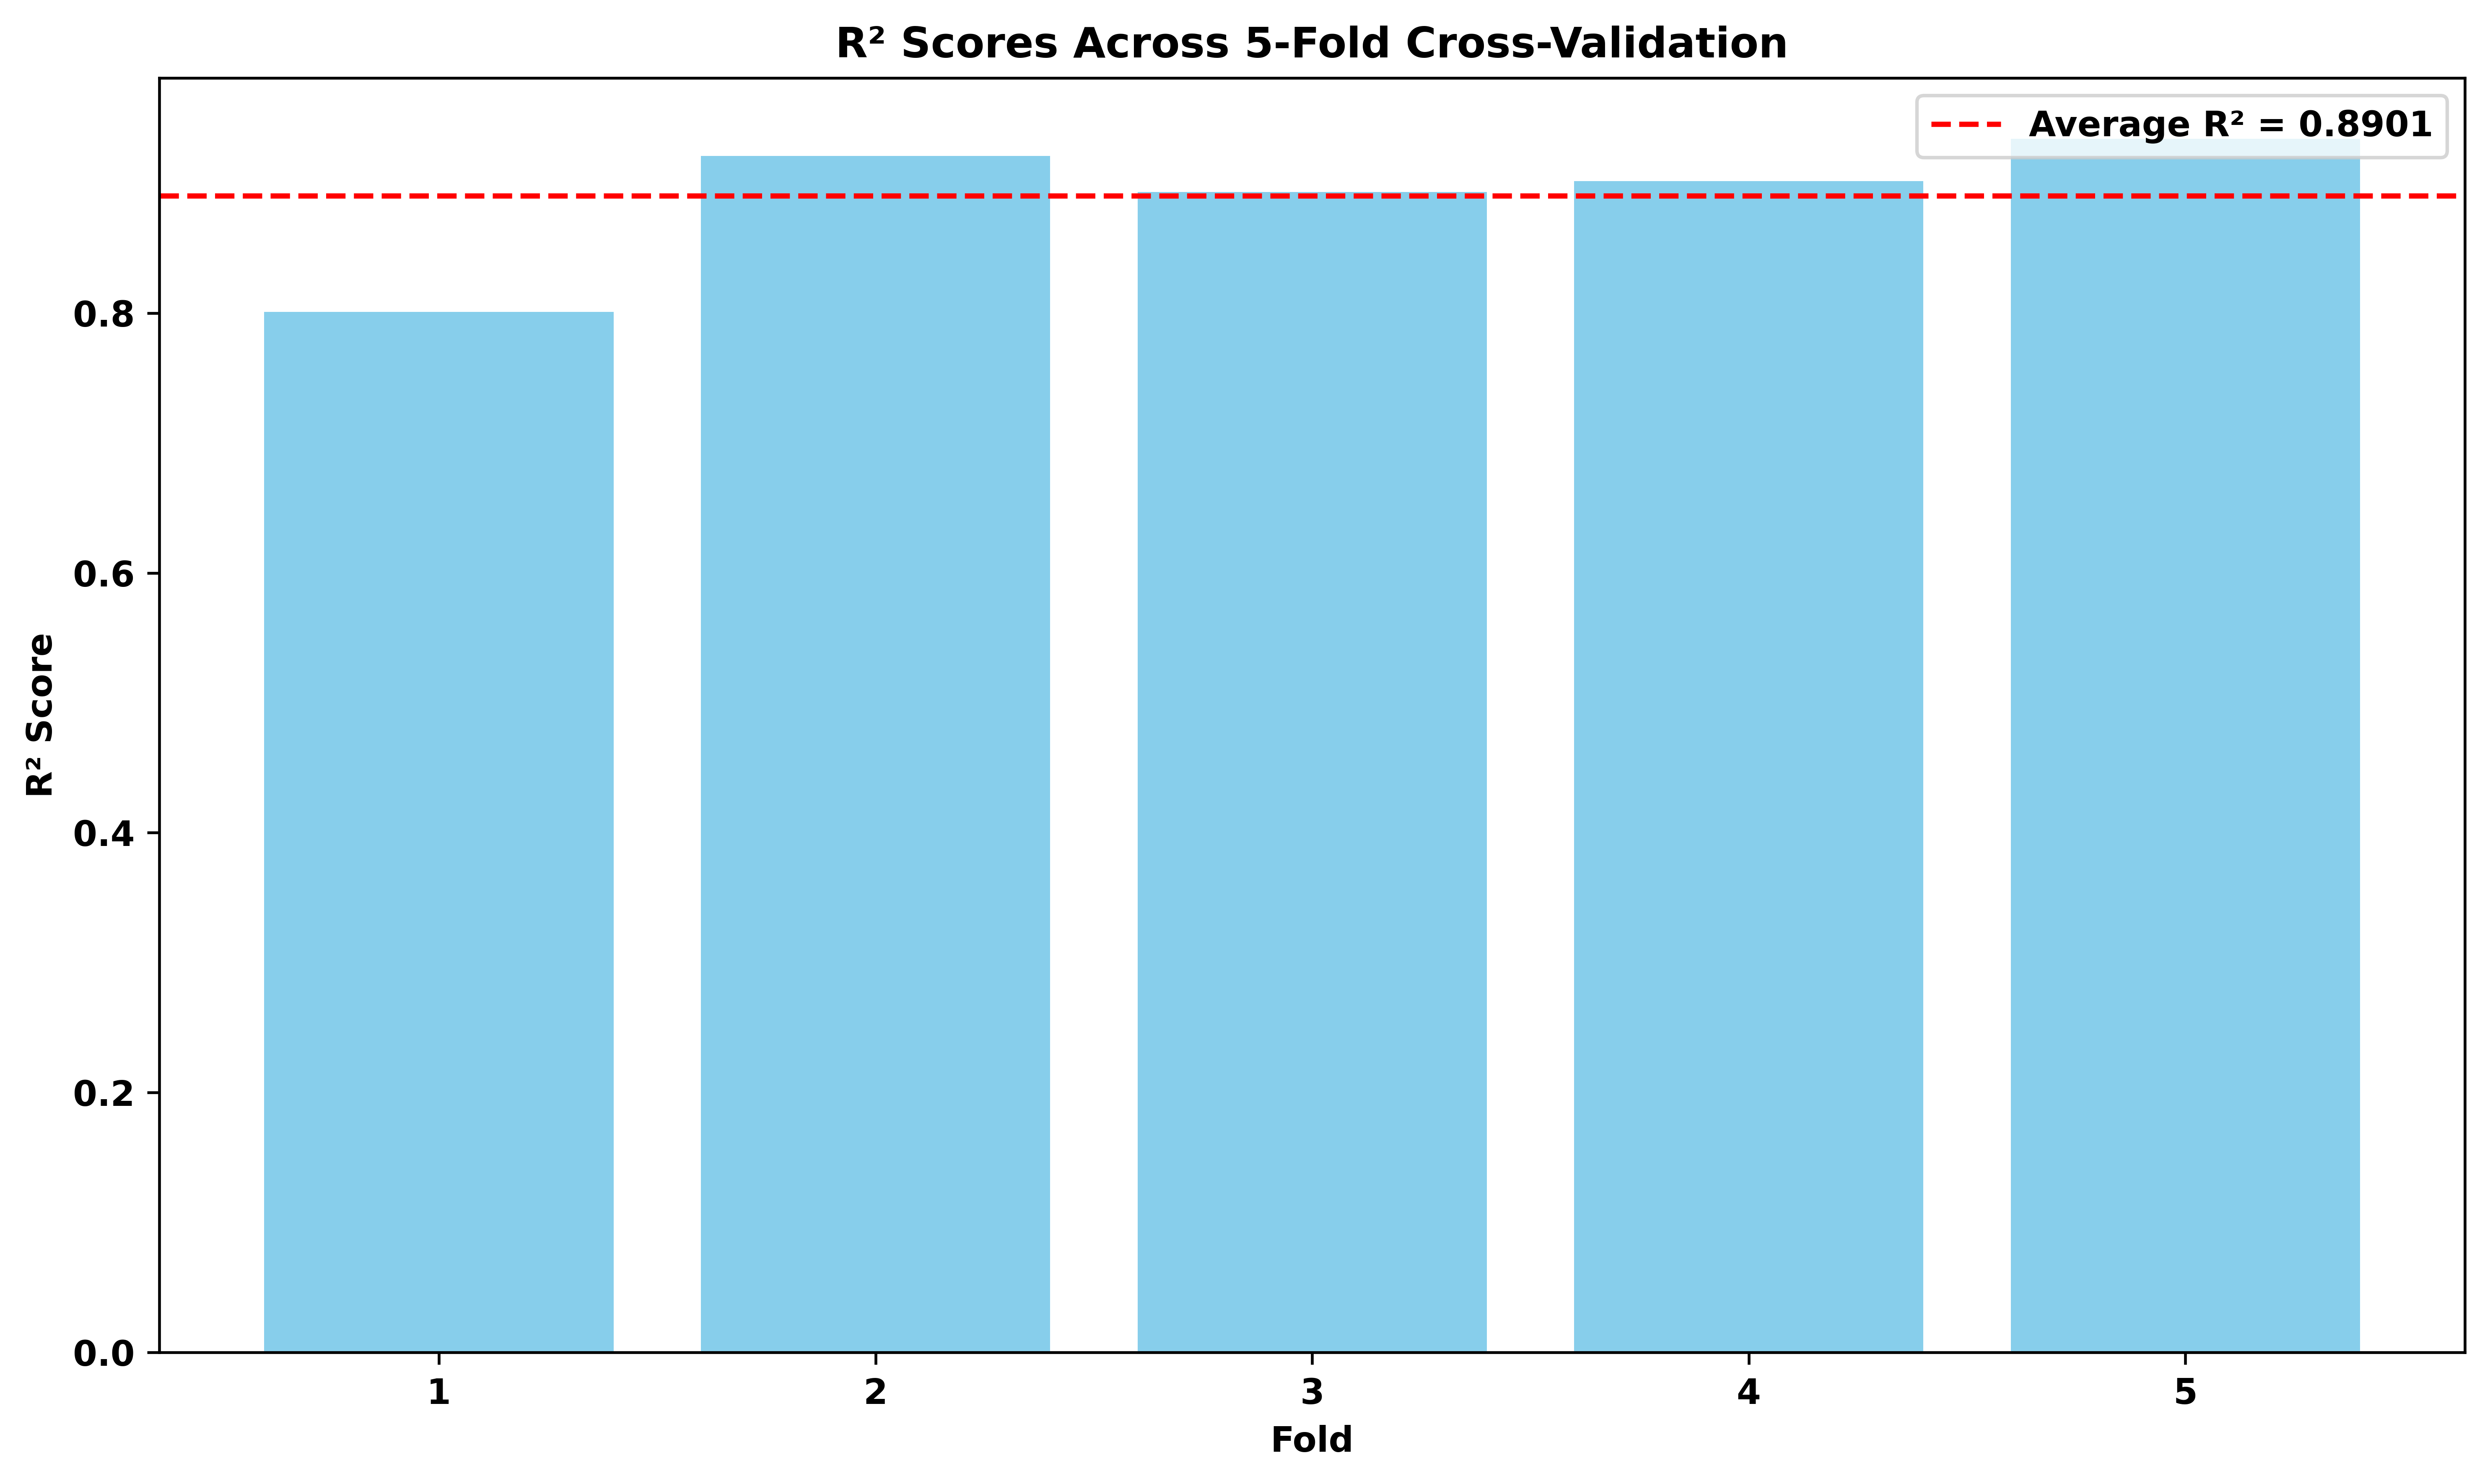

In [28]:
# IMPORTANT: define the best model parameters from grid search
best_model = RandomForestRegressor(
    criterion='squared_error', 
    max_depth=10, 
    n_estimators=200, 
    random_state=42
)
 
# initialize KFold
kf = KFold(n_splits=5, shuffle=True, random_state=42)
 
# lists to store metrics for each fold
r2_scores = []
mae_scores = []
rmse_scores = []
 
# perform cross-validation
fold = 1
for train_index, val_index in kf.split(X_train):
 
    # split data
    X_train_fold, X_val_fold = X_train[train_index], X_train[val_index]
    y_train_fold, y_val_fold = y_train[train_index], y_train[val_index]
    best_model.fit(X_train_fold, y_train_fold)
    y_val_pred = best_model.predict(X_val_fold)
    # Calculate metrics
    r2 = r2_score(y_val_fold, y_val_pred)
    mae = mean_absolute_error(y_val_fold, y_val_pred)
    rmse = np.sqrt(mean_squared_error(y_val_fold, y_val_pred))
    # store metrics here
    r2_scores.append(r2)
    mae_scores.append(mae)
    rmse_scores.append(rmse)
    # print the fold results
    print(f"Fold {fold}:")
    print(f"  R² Score: {r2:.4f}")
    print(f"  MAE: {mae:.4f}")
    print(f"  RMSE: {rmse:.4f}")
    print("-" * 30)
    fold += 1
 
# calculate and print average metrics
avg_r2 = np.mean(r2_scores)
avg_mae = np.mean(mae_scores)
avg_rmse = np.mean(rmse_scores)
std_r2 = np.std(r2_scores)
std_mae = np.std(mae_scores)
std_rmse = np.std(rmse_scores)
 
print("Cross-Validation Results (5-fold):")
print(f"Average R² Score: {avg_r2:.4f} ± {std_r2:.4f}")
print(f"Average MAE: {avg_mae:.4f} ± {std_mae:.4f}")
print(f"Average RMSE: {avg_rmse:.4f} ± {std_rmse:.4f}")
 
# plot the results for all model iterations
plt.figure(figsize=(10, 6), dpi=600)
plt.bar(range(1, 6), r2_scores, color='skyblue')
plt.axhline(y=avg_r2, color='red', linestyle='--', label=f'Average R² = {avg_r2:.4f}')
plt.xlabel('Fold', fontweight='bold')
plt.ylabel('R² Score', fontweight='bold')
plt.title('R² Scores Across 5-Fold Cross-Validation', fontweight='bold')
plt.xticks(range(1, 6), fontweight='bold')
plt.yticks(fontweight='bold')
plt.legend(prop={'weight': 'bold'})
plt.tight_layout()
plt.savefig('cv_r2_scores.png', dpi=600, bbox_inches='tight')
plt.show()

In [29]:
best =  RandomForestRegressor(criterion='absolute_error', max_depth=10, n_estimators=200, random_state=42)
model = best.fit(X_train, y_train)

In [30]:
#model = RandomForestRegressor()
#model.fit(X_train, y_train)

# Predict on the train set
y_train_pred = model.predict(X_train)

In [31]:
# Predict on the test set
y_pred = model.predict(X_test)

# Calculate metrics
r2 = r2_score(y_test, y_pred)
r2

0.904754848933753

In [36]:
mean_absolute_error(y_test, y_pred)

0.0556736416554455

In [37]:
mean_squared_error(y_test, y_pred)

0.014984644559465497

In [38]:
len(y_test)

139

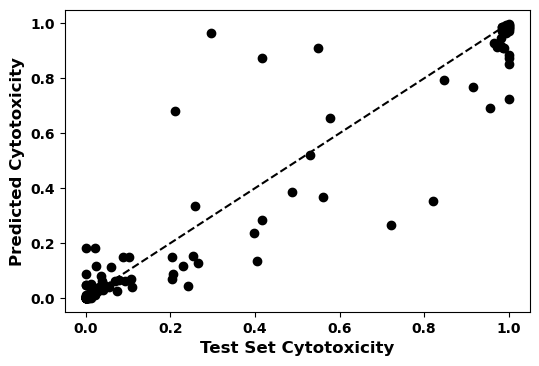

In [39]:
import matplotlib.pyplot as plt

#compound_name = "Mix5"

#df = altogether[altogether["Compound"] == compound_name]
#concentration = df["Concentration"]

# Plotting
fig, ax = plt.subplots(figsize=(6,4), dpi=100)
#plt.figure(figsize=(6,5))

plt.scatter(y_test,y_pred, color='black', marker='o', label='Cytotoxicity')
plt.plot([0, 1], [0, 1], color='black', linestyle='--', label='Ideal Prediction')

plt.xlabel('Test Set Cytotoxicity',fontweight='bold', fontsize=12)
plt.ylabel('Predicted Cytotoxicity',fontweight='bold', fontsize=12)

# Make x and y-ticks bold
#plt.xlim(0, 1)
#plt.ylim(0, 1)
plt.yticks(fontweight='bold')
plt.xticks(fontweight='bold')
#plt.legend(prop={'weight':'bold'})

#plt.legend()
plt.savefig("MD_RF_Test_Pred.png", dpi=600, bbox_inches='tight')
plt.show()

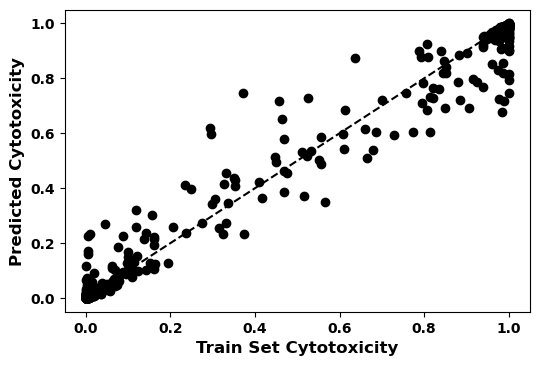

In [40]:
import matplotlib.pyplot as plt

#compound_name = "Mix5"

#df = altogether[altogether["Compound"] == compound_name]
#concentration = df["Concentration"]

# Plotting
fig, ax = plt.subplots(figsize=(6,4), dpi=100)
#plt.figure(figsize=(6,5))
plt.scatter(y_train,y_train_pred, color='black', marker='o', label='Cytotoxicity')
plt.plot([0, 1], [0, 1], color='black', linestyle='--', label='Ideal Prediction')


plt.xlabel('Train Set Cytotoxicity',fontweight='bold', fontsize=12)
plt.ylabel('Predicted Cytotoxicity',fontweight='bold', fontsize=12)

# Make x and y-ticks bold
#plt.xlim(0, 1)
#plt.ylim(0, 1)
plt.yticks(fontweight='bold')
plt.xticks(fontweight='bold')
#plt.legend(prop={'weight':'bold'})

#plt.legend()
plt.savefig("MD_RF_Train_Pred.png", dpi=600, bbox_inches='tight')
plt.show()

In [41]:
import pickle

pkl_file = 'rf_80_20_point_split_rcdk.pkl'

with open(pkl_file, 'wb') as file:
    pickle.dump(model, file)

# Train validation

In [42]:
train_predicted = model.predict(X_train)

In [43]:
r2_score(y_train, train_predicted)

0.978692308549861

In [44]:
mean_absolute_error(y_train, train_predicted)

0.02835153700682038

In [45]:
mean_squared_error(y_train, train_predicted)

0.0039245032202307965

In [46]:
# Load File

In [16]:
#import pickle

#with open("rf_80_20_point_split.pkl", 'rb') as f:
    #model = pickle.load(f)

# Let's analyze some of this

In [47]:
features = np.array(altogether.drop(columns=["Compound", "Cytotoxicity"]))

In [48]:
altogether["predicted_Cytotoxicity"] = model.predict(features)

In [49]:
test.Compound.unique()

array(['Mix13', 'Mix46', 'TBOEP', 'Mix8', 'Mix7', 'TCPP', 'Mix12', 'Zn',
       'Mix6', 'Ni', 'Mix25', 'Se', 'Mix18', 'Mix21', 'Mix48', 'Mix44',
       'Mix33', 'Mix34', 'Mix4', 'Mix42', 'EHDPHP', 'bPB', 'Mix23',
       'Mix19', 'Sb', 'Mix45', 'TCS', 'Mix11', 'TDCPP', 'Mix47', 'Cu',
       'Mix36', 'Mix38', 'Mix32', 'Mix2', 'Pb', 'PFHxS', 'Hg', 'Mix22',
       'Mix37', '2,5-DCP', 'TPhP', 'Mix30', 'Mix9', 'Mix39', 'PFNA',
       'Mix35', 'Mix41', 'PFOA', 'Mix5', 'BP-3', 'Co', 'Mix31', 'Mix14',
       'Mix1', 'pPB', 'Cd', 'TEHP', 'Mix20'], dtype=object)

In [50]:
train.Compound.unique()

array(['PFNA', 'Se', 'bPB', 'TCPP', 'Mix41', 'Mix21', 'Mix42', 'Mix7',
       'Mix33', '2,4-DCP', 'Mix4', 'Mix47', 'Mix40', 'Hg', 'Mix31',
       'Mix17', '2,5-DCP', 'Zn', 'Mix20', 'Mix13', 'Mix8', 'Mix5',
       'Mix19', 'Mix11', 'Mix14', 'Ni', 'Mix45', 'Co', 'Mix2', 'Mix48',
       'Mix39', 'TCS', 'TEHP', 'TBOEP', 'Pb', 'PFHxS', 'Mix32', 'Sb',
       'pPB', 'Cu', 'Mix28', 'Mix1', 'Mix30', 'Mix18', 'Mix22', 'TDCPP',
       'Mix44', 'Mix9', 'Mix12', 'TPhP', 'Mix25', 'Mix37', 'Cd', 'Mix6',
       'Mix36', 'Mix35', 'BP-3', 'Mix34', 'Mix38', 'PFOA', 'Mix23',
       'Mix46', 'EHDPHP'], dtype=object)

In [51]:
mix_test = test.tail(88)
mix_test

,Concentration,Compound,Cytotoxicity,Fsp3,XLogP,MW,LipinskiFailures,nRotB,MLogP,nAtomP,...,ATSp5,ATSm1,ATSm2,ATSm3,ATSm4,ATSm5,nHBDon,nHBAcc,bpol,apol
90,0.00001,Pb,1.890000e-07,0.000000,0.262662,0.444047,0.00000,0.000000,0.266667,0.000000,...,0.000000,1.000000,1.000000,0.069796,0.000000,0.000000,0.0000,0.000000,0.062218,0.000000
478,0.00008,Mix25,7.049078e-03,0.306223,0.380051,0.341027,0.18325,0.179824,0.386807,0.299413,...,0.302178,0.086896,0.132932,0.323546,0.249895,0.270103,0.5745,0.371629,0.167765,0.204435
10,0.00256,PFHxS,9.910000e-01,1.000000,0.568786,0.808775,0.00000,0.285714,0.000000,0.130435,...,0.652788,0.118944,0.289638,0.905200,0.835594,0.811344,1.0000,0.428571,0.278021,0.175376
63,0.00064,Hg,1.000000e+00,1.000000,0.251796,0.363216,0.00000,0.000000,0.333333,0.000000,...,0.000000,0.911857,0.595439,0.000000,0.000000,0.000000,0.0000,0.000000,0.085387,0.006679
456,0.00008,Mix22,1.039562e-02,0.250346,0.450344,0.314972,0.10250,0.204300,0.549277,0.414722,...,0.362698,0.038799,0.086599,0.325465,0.246648,0.235510,0.8184,0.341143,0.201077,0.274429
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
511,0.00008,Mix31,2.243375e-04,0.295200,0.335563,0.267442,0.07450,0.191371,0.290830,0.056752,...,0.177675,0.114976,0.266378,0.267927,0.166132,0.170452,0.1525,0.216386,0.229306,0.148943
24,0.00001,"2,5-DCP",3.424995e-05,0.000000,0.415230,0.099864,0.00000,0.000000,0.466667,0.304348,...,0.100439,0.032950,0.000000,0.212248,0.158705,0.095022,1.0000,0.142857,0.000000,0.100511
158,0.00004,Co,8.996344e-05,0.000000,0.262662,0.000717,0.00000,0.000000,0.266667,0.000000,...,0.000000,0.087332,0.177522,0.069796,0.000000,0.000000,0.0000,0.000000,0.083847,0.009732
521,0.00004,Mix32,1.858125e-03,0.604500,0.392205,0.448406,0.21445,0.386843,0.428483,0.184613,...,0.376618,0.115600,0.264120,0.320500,0.219484,0.292844,0.0000,0.427129,0.400178,0.347609


In [52]:
mix_test.Compound.unique()

array(['Pb', 'Mix25', 'PFHxS', 'Hg', 'Mix22', 'Mix34', 'Mix37', 'Mix33',
       '2,5-DCP', 'TPhP', 'Mix30', 'Se', 'Mix12', 'TCPP', 'Sb', 'Mix6',
       'Mix42', 'Mix13', 'Mix48', 'Mix9', 'Mix39', 'PFNA', 'EHDPHP',
       'Mix35', 'Mix47', 'Mix41', 'PFOA', 'Mix5', 'BP-3', 'Cu', 'bPB',
       'Zn', 'Co', 'Mix31', 'Mix7', 'Mix14', 'Mix1', 'pPB', 'Cd', 'TCS',
       'TDCPP', 'TEHP', 'Mix11', 'Mix4', 'Mix20', 'Mix44', 'Mix32'],
      dtype=object)

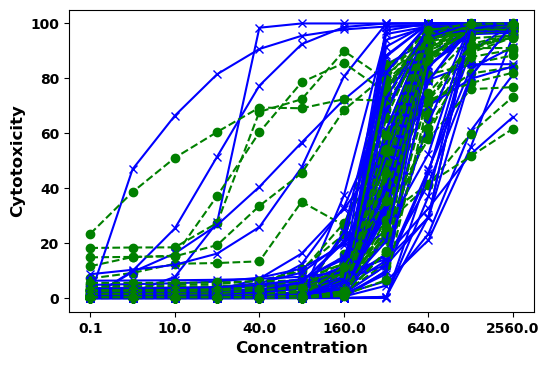

In [53]:
import matplotlib.pyplot as plt

# Plotting
fig, ax = plt.subplots(figsize=(6,4), dpi=100)

for compound_name in altogether.Compound.unique():
    
    df = altogether[altogether["Compound"] == compound_name]
    
    plt.plot([str(i*1000000) for i in df.Concentration], df['Cytotoxicity']*100, color='blue', marker='x', linestyle='-')
    plt.plot([str(i*1000000) for i in df.Concentration], df['predicted_Cytotoxicity']*100, color='green', marker='o', linestyle='--')
    
   
plt.xlabel('Concentration',fontweight='bold', fontsize=12)
plt.ylabel('Cytotoxicity',fontweight='bold', fontsize=12)
# Get all x-tick positions
all_xticks = [str(i*1000000) for i in df.Concentration]
# Show only every nth tick (adjust n as needed)
n = 2  # Show every 2nd tick
plt.xticks(all_xticks[::n], all_xticks[::n], fontweight='bold')
# Make y-ticks bold too
plt.yticks(fontweight='bold')
#plt.legend(prop={'weight':'bold'})
#plt.legend()
plt.savefig("MD_RF_Test_All.png", dpi=600, bbox_inches='tight')
plt.show()

In [54]:
mix_only = altogether[altogether['Compound'].str.contains('Mix')]

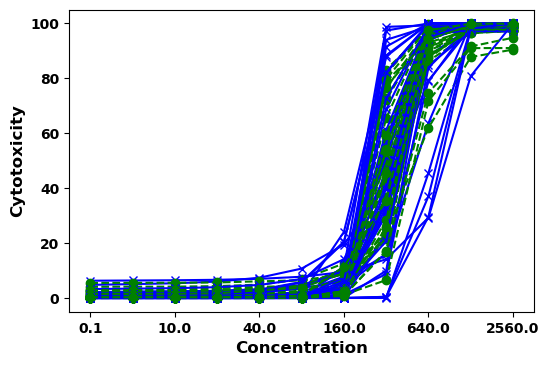

In [55]:
import matplotlib.pyplot as plt

# Plotting
fig, ax = plt.subplots(figsize=(6,4), dpi=100)

for compound_name in mix_only.Compound.unique():
    
    df = mix_only[mix_only["Compound"] == compound_name]
    
    plt.plot([str(i*1000000) for i in df.Concentration], df['Cytotoxicity']*100, color='blue', marker='x', linestyle='-')
    plt.plot([str(i*1000000) for i in df.Concentration], df['predicted_Cytotoxicity']*100, color='green', marker='o', linestyle='--')
    

plt.xlabel('Concentration',fontweight='bold', fontsize=12)
plt.ylabel('Cytotoxicity',fontweight='bold', fontsize=12)
# Get all x-tick positions
all_xticks = [str(i*1000000) for i in df.Concentration]
# Show only every nth tick (adjust n as needed)
n = 2  # Show every 2nd tick
plt.xticks(all_xticks[::n], all_xticks[::n], fontweight='bold')
# Make y-ticks bold too
plt.yticks(fontweight='bold')
#plt.legend(prop={'weight':'bold'})
#plt.legend()
plt.savefig("MD_RF_Test_Mixtures.png", dpi=600, bbox_inches='tight')
plt.show()

In [56]:
single_only = altogether[~altogether['Compound'].str.contains('Mix')]

In [57]:
single_only

,Concentration,Compound,Cytotoxicity,Fsp3,XLogP,MW,LipinskiFailures,nRotB,MLogP,nAtomP,...,ATSm1,ATSm2,ATSm3,ATSm4,ATSm5,nHBDon,nHBAcc,bpol,apol,predicted_Cytotoxicity
0,1.000000e-07,PFHxS,3.100000e-20,1.0,0.568786,0.808775,0.0,0.285714,0.0,0.130435,...,0.118944,0.289638,0.905200,0.835594,0.811344,1.0,0.428571,0.278021,0.175376,0.003219
1,5.000000e-06,PFHxS,2.940000e-09,1.0,0.568786,0.808775,0.0,0.285714,0.0,0.130435,...,0.118944,0.289638,0.905200,0.835594,0.811344,1.0,0.428571,0.278021,0.175376,0.003219
2,1.000000e-05,PFHxS,2.270000e-07,1.0,0.568786,0.808775,0.0,0.285714,0.0,0.130435,...,0.118944,0.289638,0.905200,0.835594,0.811344,1.0,0.428571,0.278021,0.175376,0.003219
3,2.000000e-05,PFHxS,1.494304e-05,1.0,0.568786,0.808775,0.0,0.285714,0.0,0.130435,...,0.118944,0.289638,0.905200,0.835594,0.811344,1.0,0.428571,0.278021,0.175376,0.003380
4,4.000000e-05,PFHxS,7.297822e-04,1.0,0.568786,0.808775,0.0,0.285714,0.0,0.130435,...,0.118944,0.289638,0.905200,0.835594,0.811344,1.0,0.428571,0.278021,0.175376,0.004196
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
259,1.600000e-04,TBOEP,1.507378e-01,1.0,0.408944,0.803862,0.5,1.000000,0.7,0.217391,...,0.072553,0.276408,0.441231,0.282103,0.334283,0.0,1.000000,0.886129,0.775382,0.126000
260,3.200000e-04,TBOEP,5.331098e-01,1.0,0.408944,0.803862,0.5,1.000000,0.7,0.217391,...,0.072553,0.276408,0.441231,0.282103,0.334283,0.0,1.000000,0.886129,0.775382,0.535517
261,6.400000e-04,TBOEP,9.720049e-01,1.0,0.408944,0.803862,0.5,1.000000,0.7,0.217391,...,0.072553,0.276408,0.441231,0.282103,0.334283,0.0,1.000000,0.886129,0.775382,0.958254
262,1.280000e-03,TBOEP,9.918885e-01,1.0,0.408944,0.803862,0.5,1.000000,0.7,0.217391,...,0.072553,0.276408,0.441231,0.282103,0.334283,0.0,1.000000,0.886129,0.775382,0.987695


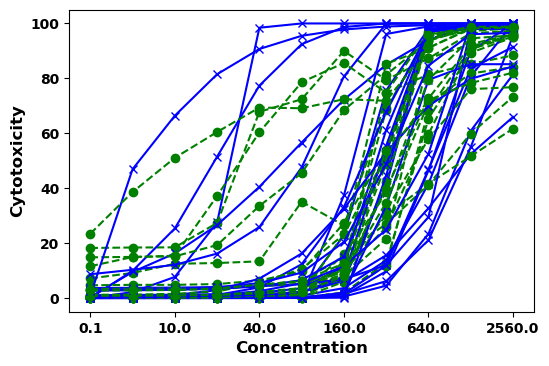

In [58]:
import matplotlib.pyplot as plt

# Plotting
fig, ax = plt.subplots(figsize=(6,4), dpi=100)

for compound_name in single_only.Compound.unique():
    
    df = single_only[single_only["Compound"] == compound_name]
    
    plt.plot([str(i*1000000) for i in df.Concentration], df['Cytotoxicity']*100, color='blue', marker='x', linestyle='-')
    plt.plot([str(i*1000000) for i in df.Concentration], df['predicted_Cytotoxicity']*100, color='green', marker='o', linestyle='--')
    

plt.xlabel('Concentration',fontweight='bold', fontsize=12)
plt.ylabel('Cytotoxicity',fontweight='bold', fontsize=12)
# Get all x-tick positions
all_xticks = [str(i*1000000) for i in df.Concentration]
# Show only every nth tick (adjust n as needed)
n = 2  # Show every 2nd tick
plt.xticks(all_xticks[::n], all_xticks[::n], fontweight='bold')
# Make y-ticks bold too
plt.yticks(fontweight='bold')
#plt.legend(prop={'weight':'bold'})
#plt.legend()
plt.savefig("MD_RF_Test_Compounds.png", dpi=600, bbox_inches='tight')
plt.show()

In [59]:
import matplotlib.pyplot as plt
import matplotlib as mpl

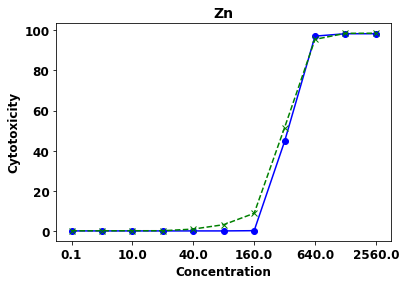

In [60]:

# Set global font properties to bold
plt.rcParams['font.weight'] = 'bold'
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['axes.labelweight'] = 'bold'
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['ytick.labelsize'] = 12
 
# Example of improved plot function
def plot_compound(compound_name, dataframe):
    df = dataframe[dataframe["Compound"] == compound_name]
    # Plotting with improved settings
    fig, ax = plt.subplots(figsize=(6,4))
    # Plot data
    plt.plot([str(i*1000000) for i in df.Concentration], df['Cytotoxicity']*100, 
             color='blue', marker='o', linestyle='-', label='Cytotoxicity')
    plt.plot([str(i*1000000) for i in df.Concentration], df['predicted_Cytotoxicity']*100, 
             color='green', marker='x', linestyle='--', label='Predicted Cytotoxicity')
    # Set title and labels with bold font
    plt.title(compound_name, fontweight='bold', fontsize=14)
    plt.xlabel('Concentration', fontweight='bold', fontsize=12)
    plt.ylabel('Cytotoxicity', fontweight='bold', fontsize=12)
    # Reduce x-axis ticks by showing fewer ticks
    # Get all x-tick positions
    all_xticks = [str(i*1000000) for i in df.Concentration]
    # Show only every nth tick (adjust n as needed)
    n = 2  # Show every 2nd tick
    plt.xticks(all_xticks[::n], all_xticks[::n], fontweight='bold')
    # Make y-ticks bold too
    plt.yticks(fontweight='bold')
    #plt.legend(prop={'weight':'bold'})
    # Save with 600 dpi
    plt.savefig(f"figures/{compound_name}_MD_RF_manuscript.png", dpi=600, bbox_inches='tight')
    plt.show()
 
# here is the function call for a specific compound
plot_compound(compound_name = "Zn", dataframe = altogether)


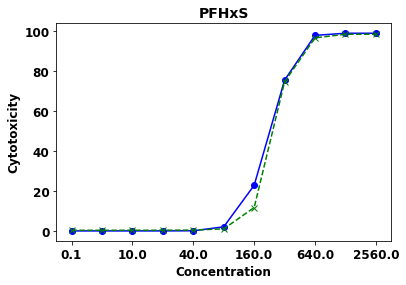

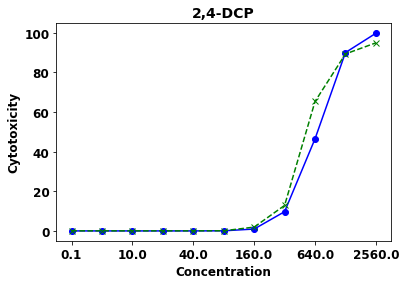

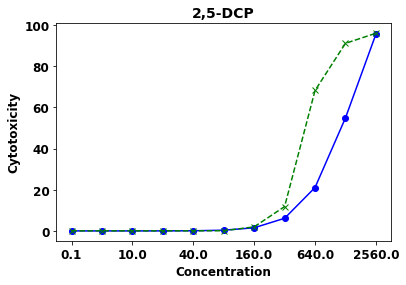

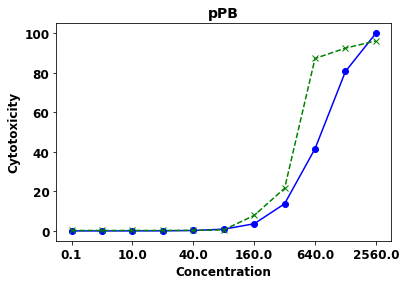

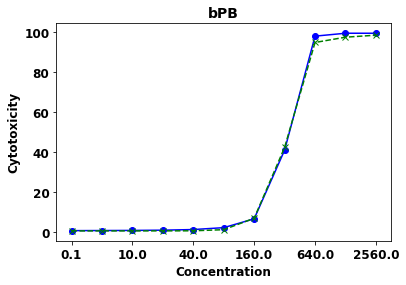

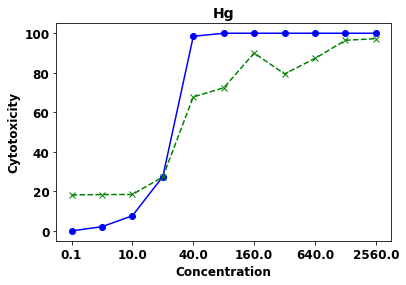

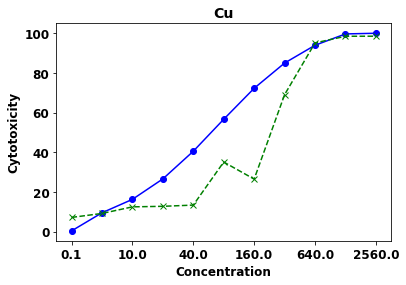

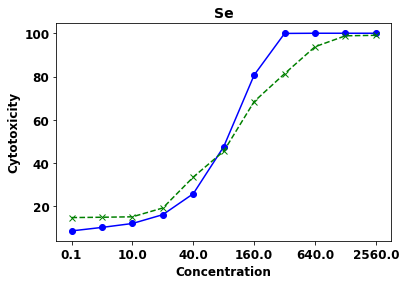

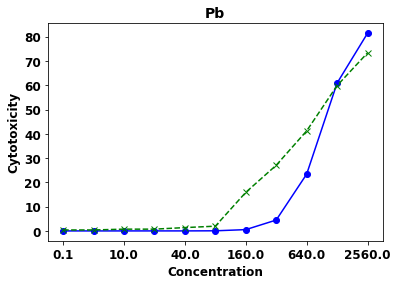

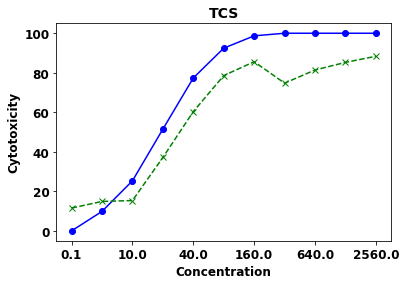

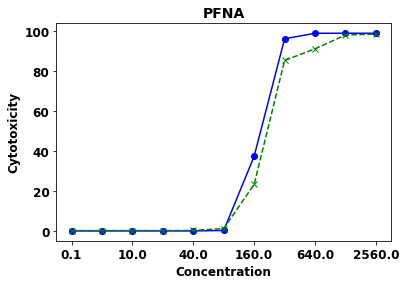

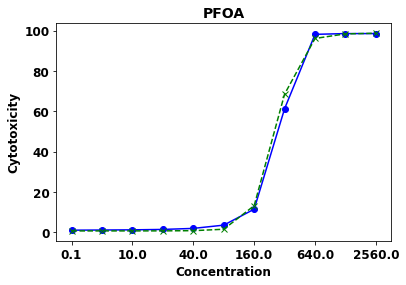

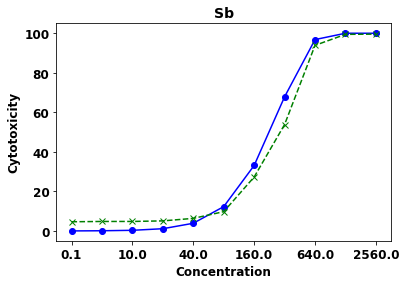

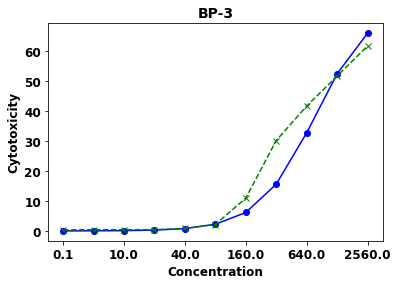

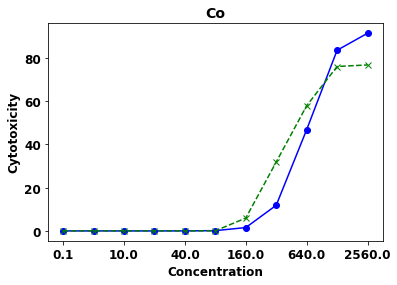

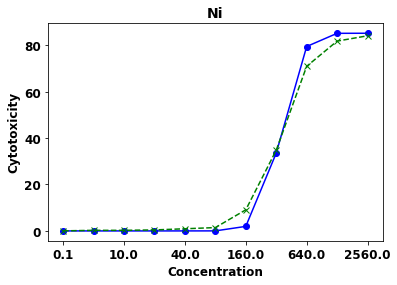

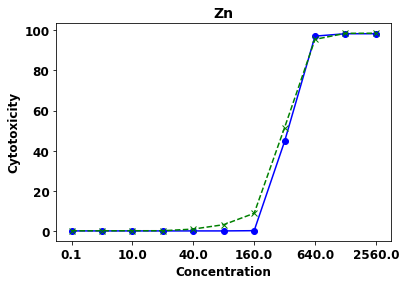

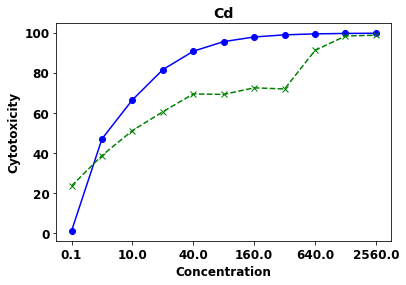

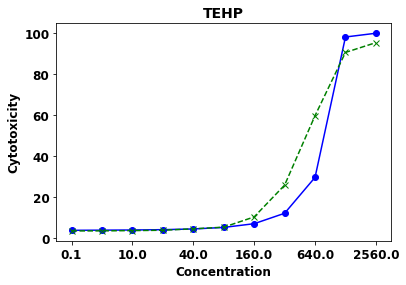

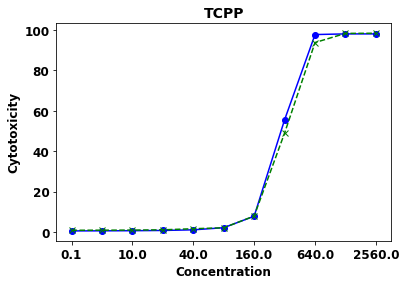

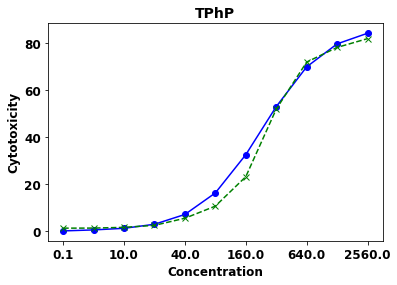

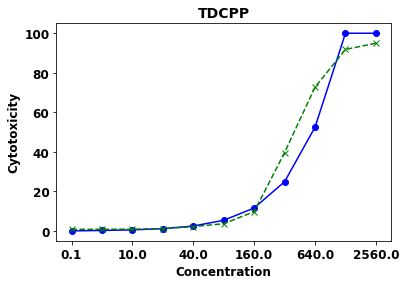

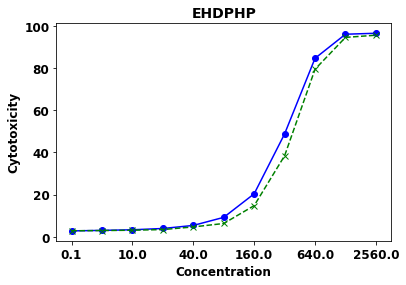

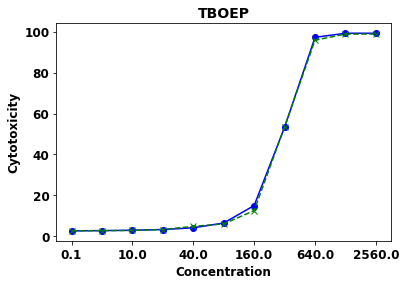

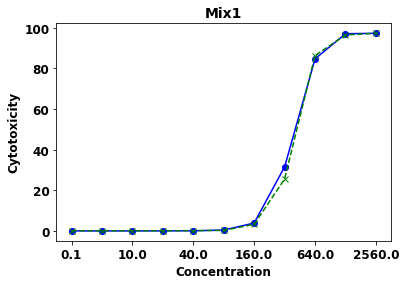

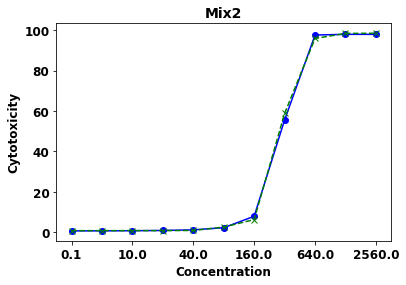

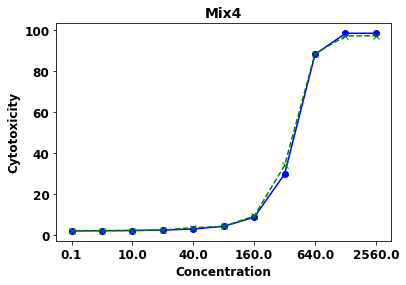

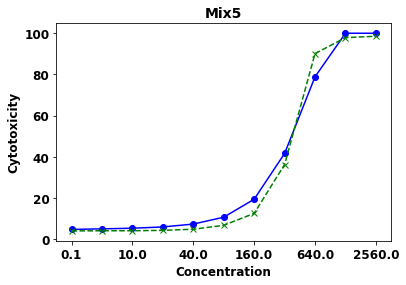

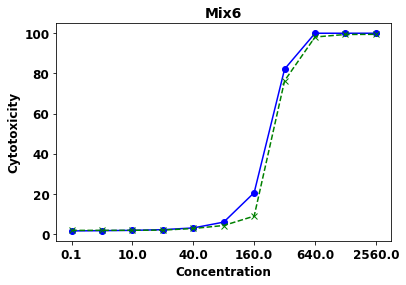

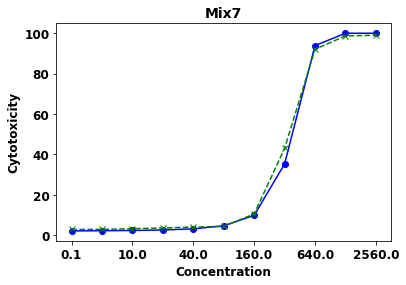

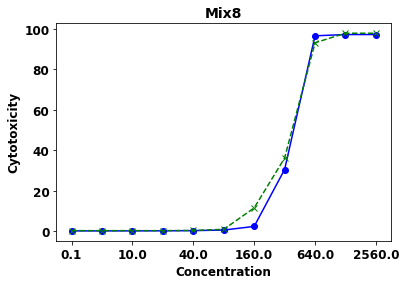

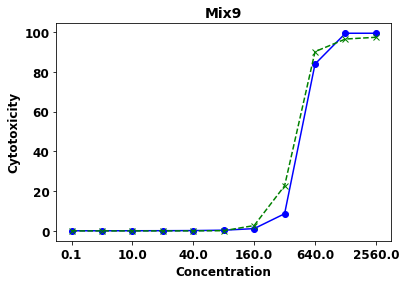

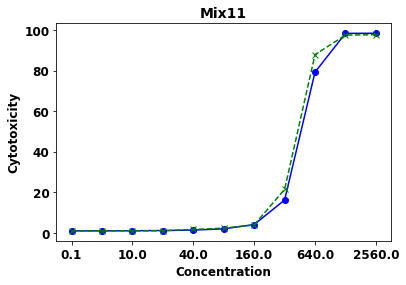

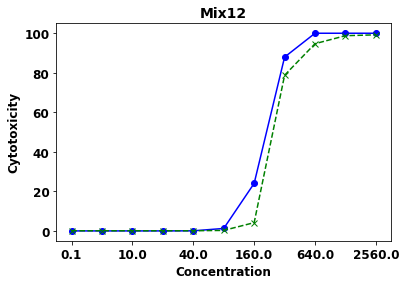

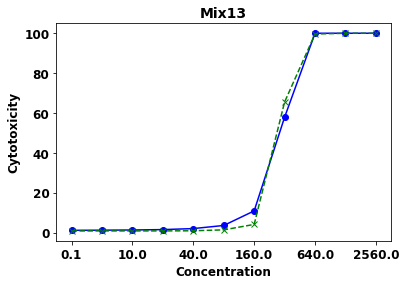

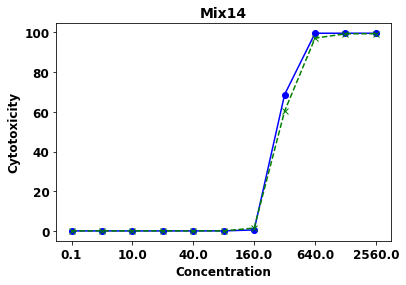

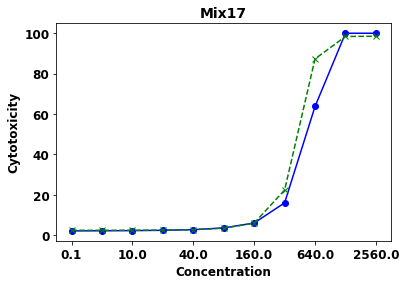

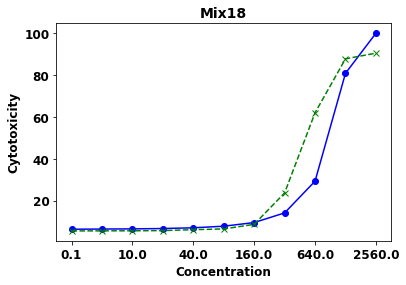

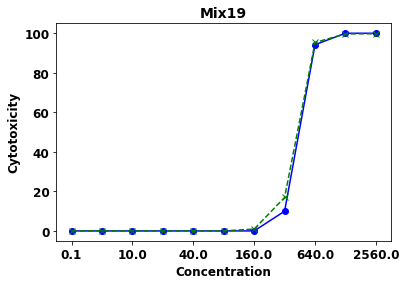

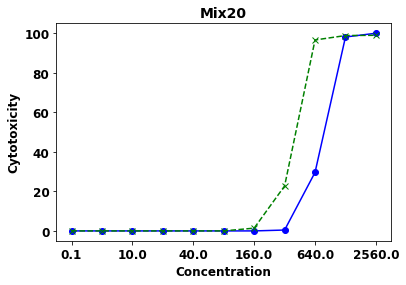

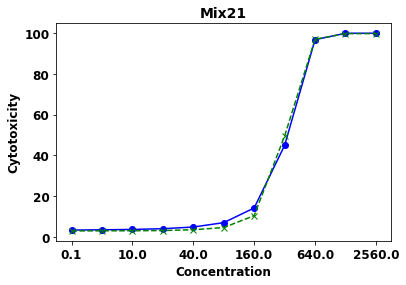

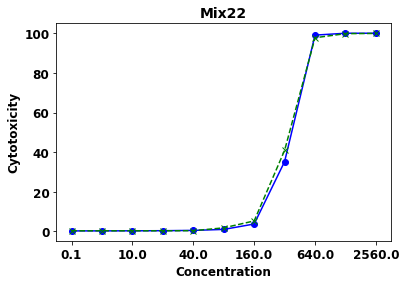

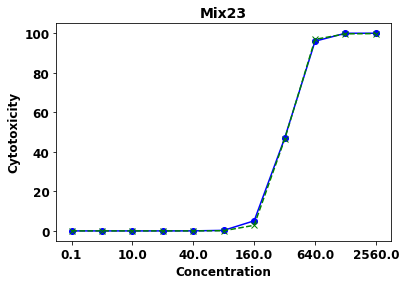

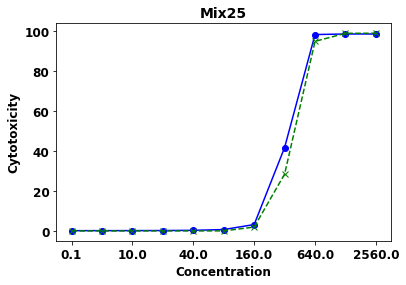

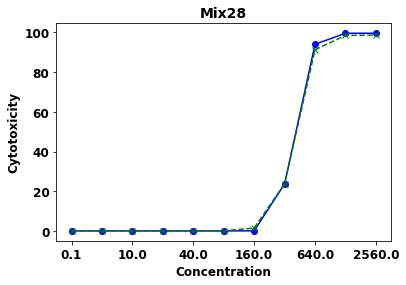

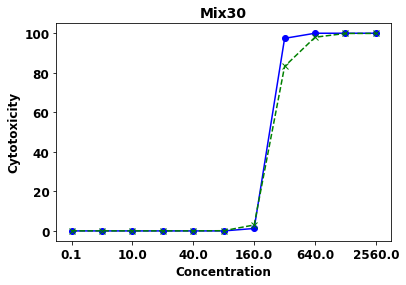

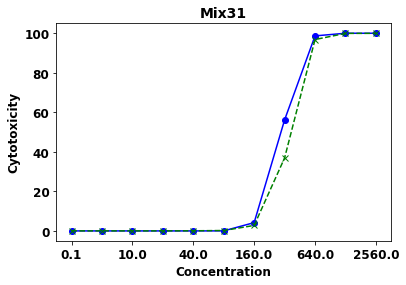

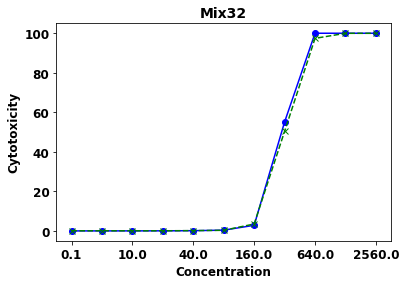

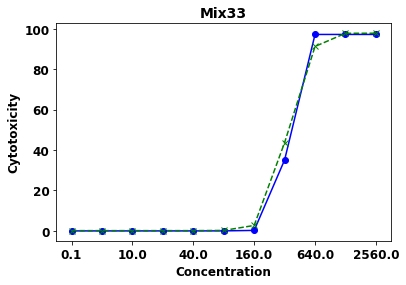

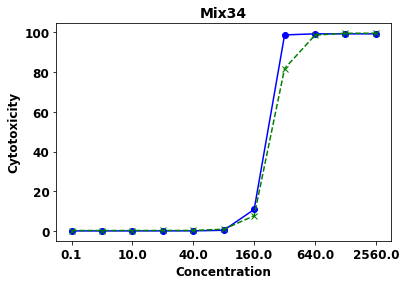

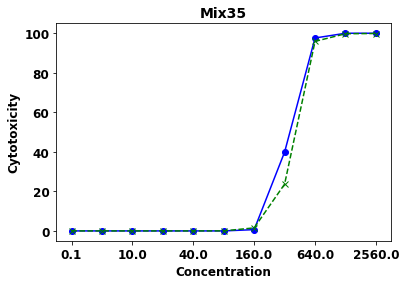

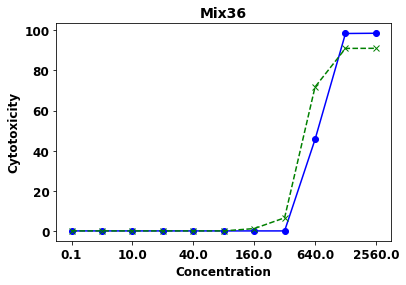

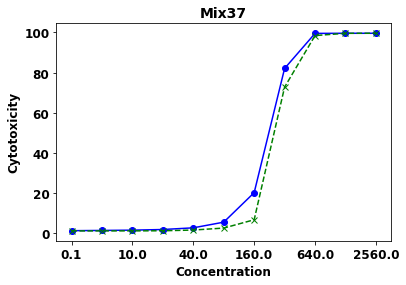

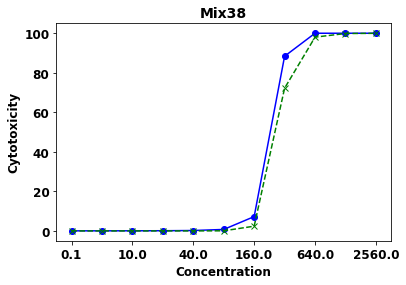

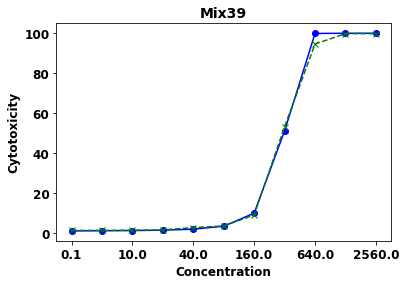

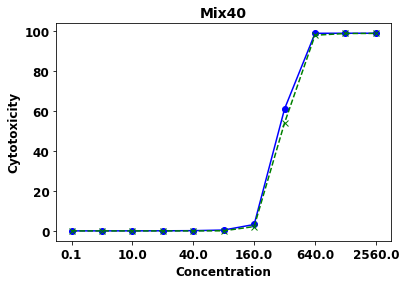

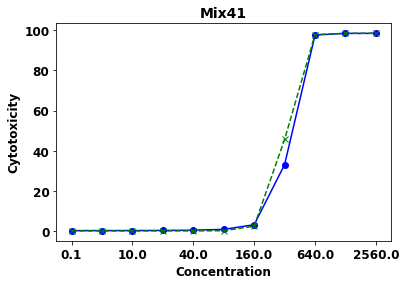

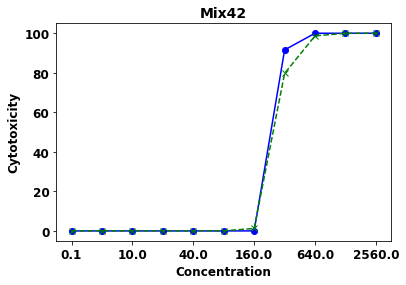

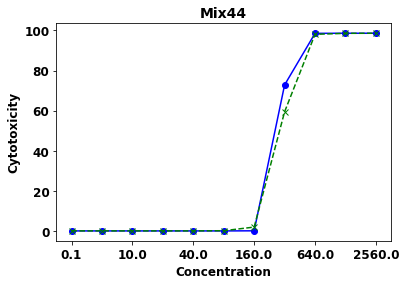

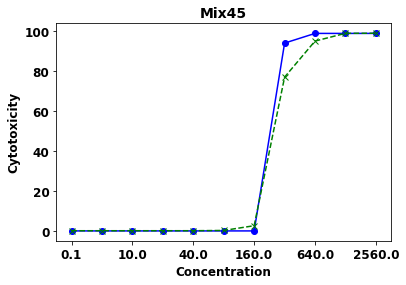

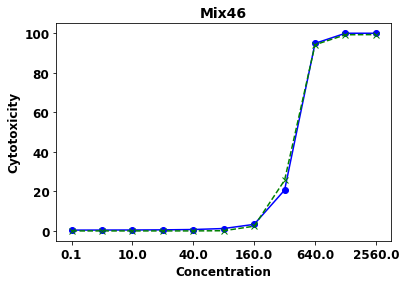

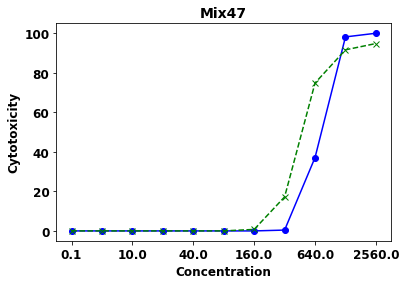

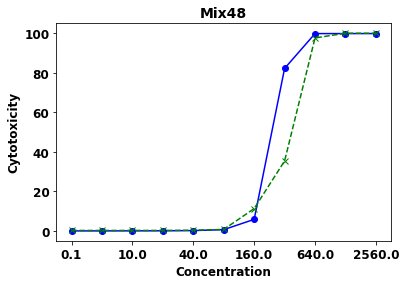

In [66]:
for i in altogether.Compound.unique():
    plot_compound(compound_name = i, dataframe = altogether)